# 11 — Advanced EDA Block 7: Predictive Models

**PACE Phase**: Analyze (advanced)
**Objective**: build predictive models to anticipate crime volume,
predict the probability of a case being cleared, and identify
co-occurrence and re-victimization patterns.

**Input**: `data/processed/crimes_features.parquet`

**Research questions addressed**:
- Q7.1 — 7-day crime volume forecast (Prophet)
- Q7.2 — Predictive clearance model (Random Forest)
- Q7.3 — Spatio-temporal co-occurrence
- Q7.4 — Re-victimization patterns

**Tools used and rationale**:
- **Prophet** (Meta): time series model for forecasting crime
  volume. Chosen over ARIMA because it natively handles weekly and
  annual seasonality, is robust to outliers, and doesn't require
  the data to be stationary
- **scikit-learn** (Random Forest, Logistic Regression): classification
  models for predicting the probability of a case being cleared.
  Random Forest chosen for its robustness, interpretability via
  feature importance, and ability to handle categorical and numeric variables
  without complex preprocessing
- **pandas** for building the spatio-temporal windows
  in the Q7.3 and Q7.4 analyses

In [1]:
import pandas as pd             # Import the Pandas framework for DataFrame manipulation
import numpy as np              # Import the Numpy framework to handle numeric operations
import seaborn as sns           # Import Seaborn for statistical visualizations
import matplotlib.pyplot as plt # Import Matplotlib for plotting

#Module for Q7.1
from prophet import Prophet # Time series forecasting model, handles weekly/yearly seasonality natively

#Modules for Q7.2
from sklearn.ensemble import RandomForestClassifier   # Classification model for the clearance prediction
from sklearn.model_selection import train_test_split  # Splits data into train/test sets
from sklearn.metrics import classification_report     # Precision/recall/F1 summary for the trained model

from mlxtend.frequent_patterns import apriori, association_rules # Frequent-itemset mining and rule extraction, for Q7.3
from mlxtend.preprocessing import TransactionEncoder              # Turns transaction lists into a one-hot matrix

pd.set_option('display.max_rows', None)         # Pandas setting to show all rows with inspection commands
pd.set_option('display.max_columns', None)      # Pandas setting to show all columns with inspection commands
pd.set_option('display.max_info_columns', 200)  # Pandas setting to show info for 200 columns with the '.info()' command

df = pd.read_parquet('../../data/processed/crimes_features.parquet') # Create the variable 'df' containing the
                                                                      # enriched dataset produced by 04_feature_engineering.ipynb
df.head() # Display the first 5 rows to recall the DataFrame's columns

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q7.1 — 7-day crime volume forecast

A time series model is built to forecast the expected crime volume for the next 7 days,
using the entire dataset history
(2010–2023) as training data and 2024 as the test period.

**Objective**: assess whether the daily crime volume is predictable
and with what accuracy. Target: MAPE (Mean Absolute Percentage Error) < 15%.

**Tool**: Prophet (Meta) — natively handles weekly and
annual seasonality, outliers, and holidays.

In [2]:
daily_crimes = (
    df
    .groupby('DATE OCC')
    .size() # Count total crimes per day, across all categories and areas
    .reset_index(name='y')
    .rename(columns={'DATE OCC': 'ds'}) # Prophet requires the date column named 'ds' and the target 'y'
)
daily_crimes['ds'] = pd.to_datetime(daily_crimes['ds'])
daily_crimes = daily_crimes.sort_values('ds')
print(daily_crimes.head(10))
print(f'Shape: {daily_crimes.shape}')

          ds     y
0 2010-01-01  2354
1 2010-01-02   535
2 2010-01-03   539
3 2010-01-04   559
4 2010-01-05   548
5 2010-01-06   532
6 2010-01-07   550
7 2010-01-08   605
8 2010-01-09   631
9 2010-01-10   618
Shape: (5478, 2)


In [3]:
train = daily_crimes[daily_crimes['ds'] < '2023-01-01'] # Train on 2010-2022
test = daily_crimes[daily_crimes['ds'] >= '2023-01-01']  # Evaluate on 2023-2024

print(f'Train: {train.shape} — from {train["ds"].min().date()} to {train["ds"].max().date()}')
print(f'Test: {test.shape} — from {test["ds"].min().date()} to {test["ds"].max().date()}')

Train: (4748, 2) — from 2010-01-01 to 2022-12-31
Test: (730, 2) — from 2023-01-01 to 2024-12-30


In [4]:
model = Prophet(
    yearly_seasonality=True,   # Capture the annual crime cycle (e.g. seasonal patterns from Q1.4)
    weekly_seasonality=True,   # Capture the day-of-week pattern
    daily_seasonality=False,   # Not applicable: the target is already a daily total
    changepoint_prior_scale=0.05 # Default flexibility for detecting trend changes; lower = smoother trend
)

model.fit(train)
print('Model trained.')

14:11:23 - cmdstanpy - INFO - Chain [1] start processing
14:11:24 - cmdstanpy - INFO - Chain [1] done processing


Model trained.


In [5]:
future = model.make_future_dataframe(periods=len(test)) # Extend the training timeline by one row per test-set day
forecast = model.predict(future) # Predict 'yhat' (and its confidence interval) for every date, train and future

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

             ds        yhat  yhat_lower  yhat_upper
5468 2024-12-21  754.181062  600.300642  898.304653
5469 2024-12-22  729.355641  575.052686  885.622140
5470 2024-12-23  748.338332  601.962004  901.490043
5471 2024-12-24  736.663361  585.971294  897.498160
5472 2024-12-25  746.442380  590.697353  900.613591
5473 2024-12-26  742.549794  584.500868  891.690113
5474 2024-12-27  796.264767  634.432326  950.149029
5475 2024-12-28  760.059689  610.267384  912.881799
5476 2024-12-29  735.156130  586.508696  882.951355
5477 2024-12-30  754.003292  607.502796  906.775723


In [6]:
test_2023 = test[test['ds'].dt.year == 2023].copy() # Evaluate on 2023 only, since 2024 is known to be incomplete
forecast_2023 = forecast[forecast['ds'].dt.year == 2023][['ds', 'yhat']].copy()

merged = test_2023.merge(forecast_2023, on='ds') # Align actual ('y') and predicted ('yhat') values by date
merged['mape'] = abs(merged['y'] - merged['yhat']) / merged['y'] * 100 # Mean Absolute Percentage Error, per day

mape = merged['mape'].mean()
print(f'MAPE on 2023: {mape:.2f}%')
print(f'Average real crimes 2023: {merged["y"].mean():.0f}')
print(f'Average predicted crimes 2023: {merged["yhat"].mean():.0f}')

MAPE on 2023: 10.74%
Average real crimes 2023: 636
Average predicted crimes 2023: 682


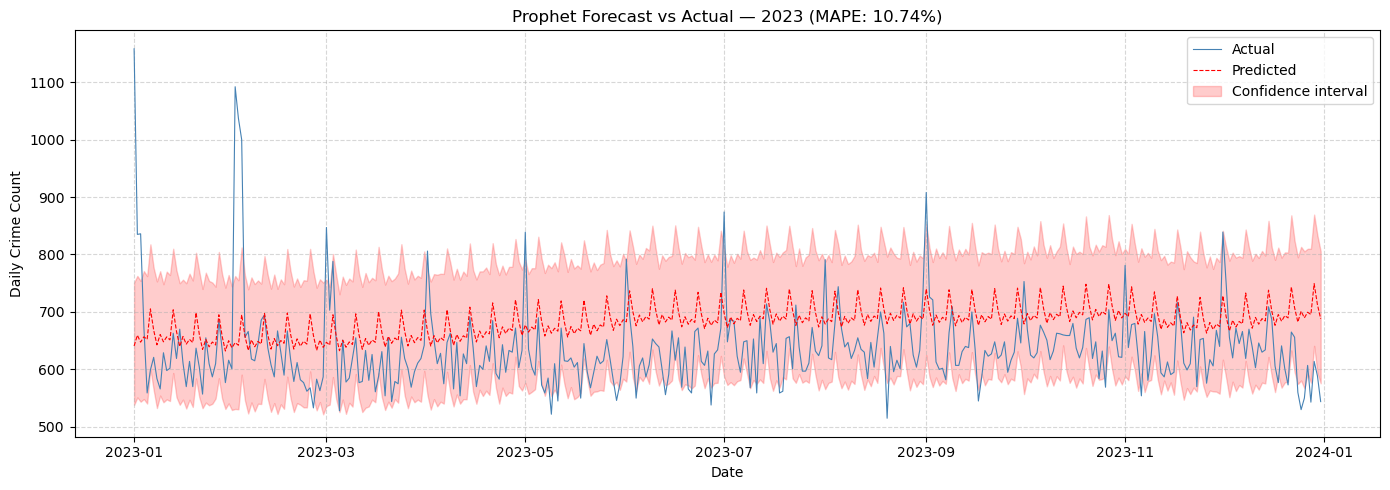

In [7]:
fig, ax = plt.subplots(figsize=(14, 5)) # Create the figure
ax.plot(merged['ds'], merged['y'], label='Actual', color='steelblue', linewidth=0.8)
ax.plot(merged['ds'], merged['yhat'], label='Predicted', color='red', linewidth=0.8, linestyle='--')
ax.fill_between(
    forecast[forecast['ds'].dt.year == 2023]['ds'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_lower'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_upper'],
    alpha=0.2, color='red', label='Confidence interval' # Prophet's predicted uncertainty band
)
ax.set_title(f'Prophet Forecast vs Actual — 2023 (MAPE: {mape:.2f}%)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Crime Count')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/35_prophet_forecast_2023.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q7.1 — 7-day crime volume forecast (Prophet)

**Main result**: MAPE on 2023 = **10.74%** — below the 15%
threshold set as the objective. The model can predict
the daily crime volume with an average error of 10.74%.

**General trend**: the predicted line (red) correctly follows
the overall crime trend in 2023, capturing the
weekly seasonality (regular oscillations) and the average level.

**Systematic overestimation**: the predicted line tends to sit above
the actual one — the model slightly overestimates crime volume.
This is consistent with the fact that it was trained on years
(2010-2022) with average volumes higher than 2023,
which shows the structural decline already documented in previous blocks.

**Confidence interval**: the pink band is wide but well calibrated —
the actual line almost always falls within it. This means
the model is honest about its own uncertainty: when it says the value
will be within a certain range, the actual value indeed falls there.

**Anomalous peaks**: the actual line shows isolated spikes significantly above the predicted value — most notably in early January and February. These represent days where the actual crime volume exceeded the model's expectations by a wide margin.

**2024**: the drop in the actual line at the end of the chart is consistent with
the 2024 dataset artifact already documented in previous blocks
(incomplete dataset). The predicted line stays stable because Prophet
extrapolates the historical trend without knowing about this anomaly.

**Methodological note**: the model is trained on data aggregated
at the citywide level. Forecasts for a single LAPD area or for a
crime category would require separate models and would
involve higher MAPE due to lower volumes.

## 3. Q7.2 — Predictive clearance model

A classification model is built to predict the probability of a case being cleared (cleared vs not cleared)
based on the features available at the time of the report.

**Objective**: identify which crime characteristics most
influence the probability of case resolution, and build a
model that can support investigation prioritization.

**Target**: `Status Desc` column — cleared cases (Adult Arrest, Juv Arrest,
Adult Other, Juv Other) vs not cleared (Invest Cont, UNK)

**Features used**:
- `AREA NAME` — LAPD area where the crime occurred
- `crime_category` — macro-category (Person/Property/Other)
- `Weapon Desc` — type of weapon used
- `Vict Sex` — victim's sex
- `age_group` — victim's age group
- `Vict Descent` — victim's descent
- `report_delay` — days between the crime and the report
- `hour_bins` — time slot of the crime
- `day_of_week` — day of the week

**Tool**: Random Forest — chosen for its robustness, ability to handle
categorical and numeric variables, and interpretability via feature importance.

In [8]:
# Column selection
q72_df = df[['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex',
             'age_group', 'Vict Descent', 'report_delay',
             'hour_bins', 'day_of_week', 'Status Desc']].copy() # Keep only the model's candidate features + target

# Create target
cleared_statuses = ['Adult Arrest', 'Juv Arrest', 'Adult Other', 'Juv Other']
q72_df['is_cleared'] = q72_df['Status Desc'].isin(cleared_statuses).astype(int) # Binary target: 1 = cleared, 0 = not cleared
q72_df = q72_df.drop(columns=['Status Desc']) # Drop the original status column, now redundant with 'is_cleared'

# Remove NaN
q72_df = q72_df.dropna() # Random Forest can't handle missing values, so incomplete rows are dropped

print(q72_df.shape)
print(q72_df['is_cleared'].value_counts())

(2447032, 10)
is_cleared
0    1848185
1     598847
Name: count, dtype: int64


In [9]:
feature_cols = ['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex',
                'age_group', 'Vict Descent', 'report_delay',
                'hour_bins', 'day_of_week']

X = pd.get_dummies(q72_df[feature_cols], drop_first=True) # One-hot encode the categorical features; 'drop_first'
                                                          # avoids redundant columns for each category
y = q72_df['is_cleared']

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]}')

Features: 138
Samples: 2447032


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # 'stratify=y' preserves the cleared/not-cleared ratio in both splits
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test: {X_test.shape[0]:,} samples')

Train: 1,957,625 samples
Test: 489,407 samples


In [11]:
model_rf = RandomForestClassifier(
    n_estimators=100,          # Number of trees in the forest
    max_depth=10,              # Limit tree depth to reduce overfitting
    class_weight='balanced',   # Compensate for the class imbalance (majority not-cleared)
    random_state=42,
    n_jobs=-1                  # Use all available CPU cores
)

model_rf.fit(X_train, y_train)
print('Model trained.')

Model trained.


In [12]:
y_pred = model_rf.predict(X_test) # Predict cleared/not-cleared on the held-out test set
print(classification_report(y_test, y_pred, target_names=['Not Cleared', 'Cleared'])) # Precision/recall/F1 per class

              precision    recall  f1-score   support

 Not Cleared       0.92      0.68      0.78    369637
     Cleared       0.45      0.82      0.58    119770

    accuracy                           0.71    489407
   macro avg       0.69      0.75      0.68    489407
weighted avg       0.81      0.71      0.73    489407



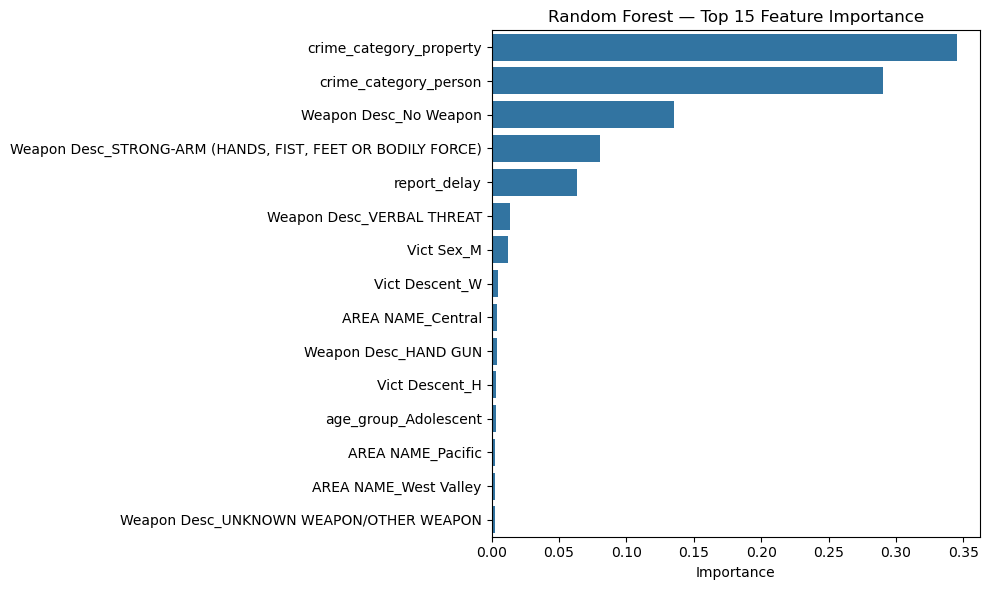

In [13]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_ # How much each one-hot feature contributes to the model's splits
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6)) # Create the figure
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/36_rf_feature_importance.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

## 4. Q7.3 — Spatio-temporal co-occurrence

Whether there are significant associations between crime types occurring in the same geographic area within a defined time window (48 hours) is analyzed.

**Objective**: identify patterns of the type "if crime A occurs
in an area, crime B is likely to also occur in the same
area within 48 hours". These patterns can inform proactive
prevention strategies.

**Method**: Association Rules

**Spatio-temporal window**: same LAPD area, within 48 hours.

In [14]:
q73_df = df[['AREA NAME', 'DATE OCC', 'Crm Cd Desc']].copy()
q73_df['DATE OCC'] = pd.to_datetime(q73_df['DATE OCC'])
q73_df['time_window'] = q73_df['DATE OCC'].dt.floor('2D') # Round down to the start of a 2-day (48h) window
q73_df['transaction_id'] = q73_df['AREA NAME'] + '_' + q73_df['time_window'].astype(str) # One "transaction" =
                                                                                         # one area + one 48h window

print(q73_df.head(10))
print(f'Unique transactions: {q73_df["transaction_id"].nunique():,}')

   AREA NAME   DATE OCC                                        Crm Cd Desc  \
0     Newton 2010-02-20                           VIOLATION OF COURT ORDER   
1    Pacific 2010-09-12  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...   
2     Newton 2010-08-09                          OTHER MISCELLANEOUS CRIME   
3  Hollywood 2010-01-05                           VIOLATION OF COURT ORDER   
4    Central 2010-01-02                                    RAPE, ATTEMPTED   
5    Central 2010-01-04           SHOPLIFTING - PETTY THEFT ($950 & UNDER)   
6    Central 2010-01-07                              BURGLARY FROM VEHICLE   
7    Central 2010-01-08     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT   
8    Central 2010-01-09     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT   
9    Central 2010-01-06  THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...   

  time_window        transaction_id  
0  2010-02-20     Newton_2010-02-20  
1  2010-09-12    Pacific_2010-09-12  
2  2010-08-09     Newton_20

In [15]:
transactions = (
    q73_df
    .groupby('transaction_id')['Crm Cd Desc']
    .apply(list) # One list of crime descriptions per area/48h transaction — the format apriori expects
    .tolist()
)

print(f'Number of transactions: {len(transactions):,}')
print(f'Example transaction: {transactions[0]}')

Number of transactions: 56,961
Example transaction: ['CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'BATTERY - SIMPLE ASSAULT', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'INTIMATE PARTNER - SIMPLE ASSAULT', 'BATTERY WITH SEXUAL CONTACT', 'VEHICLE - STOLEN', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'VEHICLE - STOLEN', 'THEFT OF IDENTITY', 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD', 'CRIMINAL THREATS - NO WEAPON DISPLAYED', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)', 'THEFT OF IDENTITY', 'BATTERY - SIMPLE ASSAULT', 'CRIMINAL THREATS - NO WEAPON DISPLAYED', 'OTHER MISCELLANEOUS CRIME', 'BURGLARY FROM VEHICLE', 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)', 'ATTEMPTED ROBBERY', 'BURGLARY', 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'BAT

In [16]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions) # One-hot encode: one column per crime type, one row per transaction
te_df = pd.DataFrame(te_array, columns=te.columns_)
print(f'Matrix shape: {te_df.shape}')
print(te_df.head(3))

Matrix shape: (56961, 143)
   ABORTION/ILLEGAL  ARSON  ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER  \
0             False  False                                         False   
1             False  False                                         False   
2             False  False                                         False   

   ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  ATTEMPTED ROBBERY  \
0                                            True               True   
1                                            True              False   
2                                            True              False   

   BATTERY - SIMPLE ASSAULT  BATTERY ON A FIREFIGHTER  \
0                      True                     False   
1                      True                     False   
2                      True                     False   

   BATTERY POLICE (SIMPLE)  BATTERY WITH SEXUAL CONTACT  \
0                    False                         True   
1                    False      

In [17]:
frequent_itemsets = apriori(
    te_df,
    min_support=0.3,      # Keep only crime combinations present in at least 30% of transactions
    use_colnames=True     # Show crime names instead of column indices in the results
)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Frequent itemsets found: 20754
      support                                           itemsets
21   0.963993                                 (VEHICLE - STOLEN)
4    0.940644                            (BURGLARY FROM VEHICLE)
16   0.932726               (THEFT PLAIN - PETTY ($950 & UNDER))
1    0.931567                         (BATTERY - SIMPLE ASSAULT)
19   0.917786  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...
109  0.909447          (BURGLARY FROM VEHICLE, VEHICLE - STOLEN)
62   0.901740       (BATTERY - SIMPLE ASSAULT, VEHICLE - STOLEN)
200  0.901599  (THEFT PLAIN - PETTY ($950 & UNDER), VEHICLE -...
3    0.901354                                         (BURGLARY)
211  0.888994  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...


In [18]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.8  # Keep only rules where the consequent follows the antecedent at least 80% of the time
)
rules = rules.sort_values('lift', ascending=False) # Lift > 1 means the association is stronger than random chance
print(f'Rules found: {len(rules)}')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Rules found: 428101
                                              antecedents  \
360502  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   
347953  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   
354274  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   
347997  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   
354226  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   
255291  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   
255240  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   
335441  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   
237719  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   
254992  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), CRI...   

                                              consequents   support  \
360502  (BATTERY - SIMPLE ASSAULT, ROBBERY, VEHICLE - ...  0.310107   
347953  (BATTERY - SIMPLE ASSAULT, ROBBERY, VEHICLE - ...  0.312723   
354274  (BATTERY - SIMPLE ASSAULT, ROBBERY, VEHICLE - ...  0.312301   
347997  (BATTERY - SIMPL

In [19]:
rules_filtered = rules[
    (rules['antecedents'].apply(lambda x: len(x)) <= 2) & # Keep simple, readable antecedents (at most 2 crimes)
    (rules['consequents'].apply(lambda x: len(x)) == 1) & # Single-crime consequent, easier to interpret
    (rules['lift'] > 1.05) # Discard associations barely above random chance
].sort_values('lift', ascending=False)

print(f'Filtered rules: {len(rules_filtered)}')
print(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Filtered rules: 123
                                           antecedents  \
2                                    (BRANDISH WEAPON)   
369  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
370  (CRIMINAL THREATS - NO WEAPON DISPLAYED, ROBBERY)   
389       (INTIMATE PARTNER - SIMPLE ASSAULT, ROBBERY)   
125            (INTIMATE PARTNER - AGGRAVATED ASSAULT)   
437  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
387  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
439  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), ROB...   
526  (VIOLATION OF RESTRAINING ORDER, VEHICLE - STO...   
287  (VIOLATION OF RESTRAINING ORDER, BATTERY - SIM...   
251                (ROBBERY, BATTERY - SIMPLE ASSAULT)   
250  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
535        (BATTERY - SIMPLE ASSAULT, BRANDISH WEAPON)   
20                    (VIOLATION OF RESTRAINING ORDER)   
436  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   

                                          consequen

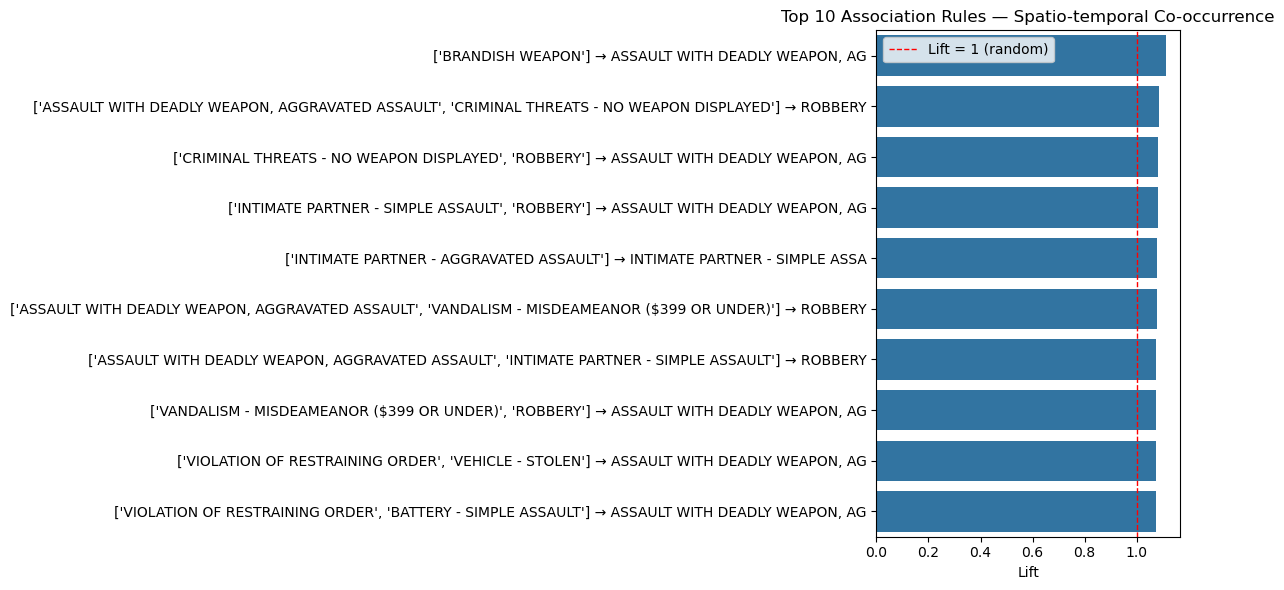

In [20]:
top_rules = rules_filtered.head(10).copy()
top_rules['rule'] = top_rules.apply(
    lambda x: f"{list(x['antecedents'])} → {list(x['consequents'])[0][:30]}", # Build a readable "A → B" label per rule
    axis=1
)

fig, ax = plt.subplots(figsize=(12, 6)) # Create the figure
sns.barplot(data=top_rules, x='lift', y='rule', ax=ax)
ax.set_title('Top 10 Association Rules — Spatio-temporal Co-occurrence')
ax.set_xlabel('Lift')
ax.set_ylabel('')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Lift = 1 (random)') # Reference line: no association
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/37_association_rules.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q7.3 — Spatio-temporal co-occurrence

**Results**: 123 association rules identified with lift > 1.05
and simple antecedents (≤ 2 crimes). The strongest rules show
associations between violent crimes:

- Brandish Weapon → Aggravated Assault (lift 1.11)
- Intimate Partner Aggravated Assault → Intimate Partner Simple Assault (lift 1.08)
- Violation of Restraining Order → Aggravated Assault (lift 1.07)

**Critical limitation — why this analysis is not being considered**:

The model aggregates crimes at the **LAPD area** level (a geographic
unit of several km²) within the same 48 hours. This means that a rule like
"Intimate Partner Aggravated Assault → Intimate Partner Simple Assault"
doesn't necessarily imply a real connection between the two events —
they could have occurred in completely different families and locations
within the same area, with no causal relationship at all.

A meaningful co-occurrence analysis would require working
with precise address- or block-level coordinates (50-100 meters),
not LAPD-area level. According to the official LAPD data documentation, address fields are provided only to the nearest hundred block in order to maintain privacy — making it impossible to distinguish events that occurred in adjacent residences within the same area.

Lift values very close to 1 (range 1.05-1.11) confirm that the associations
found are statistically marginal and not actionable for
operational planning.

**Conclusion**: the Q7.3 results are not used in the
project's conclusions for the methodological reasons described above.

## 5. Q7.4 — Re-victimization patterns

Repeat victimization patterns are identified by analyzing the concentration of 
crimes at the same address or block within 30-, 60-, and 90-day time windows.

**Objective**: pinpoint addresses or areas where the same victim
or the same location is hit repeatedly — the so-called
"repeat victims" and "hot places". These patterns allow us to
identify high-risk situations where early preventive
intervention could break the victimization cycle.

**Method**: group crimes by address (`LOCATION`) and
calculate how many addresses record more than one crime within
30-, 60-, and 90-day windows.

**Methodological note**: the analysis is at the address/block level,
not at the individual victim level — the dataset doesn't contain a
unique victim identifier that would allow tracking the same person
over time.

**Note — Q7.4 not implemented**:

The re-victimization pattern analysis by address was
dropped for two reasons:

1. **Redundancy with Block 6**: identifying repeatedly hit
   locations is conceptually equivalent to the geographic hotspot
   analysis already carried out in Q6.1 (grid hotspot map) and Q6.2
   (hotspot persistence over time). Adding an address-level analysis
   would not produce significant incremental insight.

2. **Data limitation**: According to the official LAPD data documentation, address fields are provided only to the nearest hundred block in order to maintain privacy — making the distinction between "same address" and "same 500m×500m cell" less meaningful than it seems. Additionally, the dataset doesn't contain a
   unique victim identifier, preventing re-victimization
   of a person from being distinguished from re-victimization of a location.